# UHI Classification: Brazil → Sierra Leone

**Objective:** Classify Urban Heat Island intensity (High / Medium / Low) using satellite-derived features.  
**Training data:** Brazil (Rio de Janeiro metro area, tropical climate)  
**Validation target:** Freetown, Sierra Leone (tropical coastal city)

## Notebook Overview

This notebook builds an ensemble UHI classifier trained on Rio de Janeiro and applies it to Freetown, Sierra Leone:

- **Data sources:** Sentinel-2 spectral indices, Landsat thermal, Copernicus DEM
- **Features:** 19 spectral indices + LST + 6 engineered interactions
- **Models:** 3-model ensemble (GradientBoosting @ 100m + 2× XGBoost variants)
- **Key result:** F1=0.954 on Brazil test set, excellent class separation
- **Transfer:** Tropical climate similarity supports SL generalization

## 1. Data Sources & Feature Overview

Three satellite sources, same extraction pipeline as Chile/Combined:

**Sentinel-2:** 11 raw bands + SCL cloud masking. Median composite over the time window removes transient cloud contamination while preserving stable surface reflectance. SCL flags excluded: cloud (8,9), shadow (3), cirrus (10), nodata (0), saturated (1).

**Landsat 8/9:** Single scene (not composited). Thermal band (lwir11) captures the UHI signal on one specific date. Compositing thermal data would average out the day-specific heat pattern we're trying to classify.

**Copernicus DEM:** Static elevation, extracted once.

**Time window:** Brazil = 2023-01-01 to 2023-03-15 (austral summer).

**Point spacing:** Median ~7m (denser than 10m pixels). Nearest-pixel extraction (neighborhood=0) preserves signal; spatial averaging would blur class boundaries.

## 2. Spectral Indices & LST

Same 19 Sentinel-2 indices + Landsat LST as Chile (see Chile notebook for full index table).

### LST Derivation (Mono-Window Method)

From Landsat thermal band (lwir11):

1. Compute vegetation fraction from NDVI:

$$P_v = \left(\frac{\text{NDVI} - \text{NDVI}_{\min}}{\text{NDVI}_{\max} - \text{NDVI}_{\min}}\right)^2$$

2. Estimate surface emissivity:

$$\varepsilon = 0.004 \times P_v + 0.986$$

3. Convert brightness temperature $BT$ to land surface temperature:

$$\text{LST} = \frac{BT}{1 + \left(\frac{\lambda \cdot BT}{\rho}\right) \ln(\varepsilon)}$$

where $\lambda = 10.9\,\mu m$ (TIRS band center) and $\rho = h \cdot c / \sigma = 1.438 \times 10^{-2}\,\text{m}\cdot\text{K}$.

This is not a data leak — LST is an independent satellite measurement, not the label source.

## 3. Feature Engineering

19 Sentinel-2 spectral indices + Landsat LST + 6 interaction features (LST × NDVI, LST × NDBI, elevation × LST, NDVI − NDBI, LST × Albedo, BU × LST). NDVI_Landsat dropped (redundant).

**No scaling or QuantileTransformer:** Tree models split on thresholds, invariant to monotonic transforms. Brazil's features already separate well between classes.

### Setup

In [2]:
%pip install xgboost --quiet

StatementMeta(, 46e92ce5-b70a-4cc1-9ca4-9952d043be11, 8, Finished, Available, Finished, True)


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Imports & Evaluation Framework

The `results_summary` function provides standardized metrics (F1, accuracy, precision, recall, AUC, gap analysis) for consistent model evaluation across all experiments.

In [3]:
import os, warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

DATA_DIR = "/lakehouse/default/Files/uhi_pipe_output/datasets"
OUT_DIR = "/lakehouse/default/Files/uhi_pipe_output/predictions"
os.makedirs(OUT_DIR, exist_ok=True)


def results_summary(model, X_train, X_test, y_train, y_test, le, model_name="Model"):
    """Full train/test evaluation with gap analysis and classification report."""
    y_tr_enc = le.transform(y_train) if y_train.dtype == object else y_train
    y_te_enc = le.transform(y_test) if y_test.dtype == object else y_test

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    f1_train = f1_score(y_tr_enc, pred_train, average="weighted")
    f1_test = f1_score(y_te_enc, pred_test, average="weighted")
    f1_gap = f1_train - f1_test

    acc_test = accuracy_score(y_te_enc, pred_test)
    prec_test = precision_score(y_te_enc, pred_test, average="weighted")
    rec_test = recall_score(y_te_enc, pred_test, average="weighted")

    auc = np.nan
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)
        if proba.shape[1] == len(le.classes_):
            auc = roc_auc_score(y_te_enc, proba, multi_class="ovr", average="weighted")

    print(f"{'='*60}")
    print(f"  {model_name} — Results Summary")
    print(f"{'='*60}")
    print(f"  F1 Train:     {f1_train:.4f}")
    print(f"  F1 Test:      {f1_test:.4f}")
    print(f"  F1 Gap:       {f1_gap:.4f}  {'⚠ HIGH' if abs(f1_gap) > 0.05 else '✓ stable'}")
    print(f"  Accuracy:     {acc_test:.4f}")
    print(f"  Precision:    {prec_test:.4f}")
    print(f"  Recall:       {rec_test:.4f}")
    print(f"  AUC (wt):     {auc:.4f}" if not np.isnan(auc) else "  AUC:          N/A")
    print(f"\nClassification Report:")
    print(classification_report(y_te_enc, pred_test, target_names=le.classes_))
    print(f"Confusion Matrix:")
    print(pd.DataFrame(
        confusion_matrix(y_te_enc, pred_test),
        index=[f"True_{c}" for c in le.classes_],
        columns=[f"Pred_{c}" for c in le.classes_]
    ))

    return {
        "model": model_name, "f1_train": f1_train, "f1_test": f1_test,
        "f1_gap": f1_gap, "accuracy": acc_test, "precision": prec_test,
        "recall": rec_test, "auc": auc,
    }

StatementMeta(, 46e92ce5-b70a-4cc1-9ca4-9952d043be11, 10, Finished, Available, Finished, False)

### Feature Engineering Functions

`engineer_features` creates 6 interaction terms (LST × NDVI, LST × NDBI, etc.) and drops redundant Landsat NDVI. `prepare_xy` handles missing values and constructs train/validation feature matrices.

In [4]:
def engineer_features(df):
    df = df.copy()
    df["LST_x_NDVI"] = df["LST"] * df["NDVI"]
    df["LST_x_NDBI"] = df["LST"] * df["NDBI"]
    df["elev_x_LST"] = df["elevation"] * df["LST"]
    df["NDVI_minus_NDBI"] = df["NDVI"] - df["NDBI"]
    df["LST_x_Albedo"] = df["LST"] * df["Albedo"]
    df["BU_x_LST"] = df["BU"] * df["LST"]
    if "NDVI_Landsat" in df.columns:
        df.drop(columns=["NDVI_Landsat"], inplace=True)
    return df

def prepare_xy(df):
    df = engineer_features(df)
    drop_cols = [c for c in ["Latitude","Longitude","UHI_Class","label","resolution_m"] if c in df.columns]
    y = df["UHI_Class"] if "UHI_Class" in df.columns else None
    X = df.drop(columns=drop_cols)
    X = X.fillna(X.median()).replace([np.inf, -np.inf], np.nan).fillna(0)
    return X, y

StatementMeta(, 46e92ce5-b70a-4cc1-9ca4-9952d043be11, 11, Finished, Available, Finished, False)

## 4. Data Loading & Class Distribution

Load 100m and 250m resolution datasets. Brazil is imbalanced: 45% High / 37% Low / 18% Medium. This imbalance reflects real urban geography (more core urban + periphery than transition zones).

In [5]:
df_100 = pd.read_csv(f"{DATA_DIR}/ML_Dataset_100m.csv")
df_250 = pd.read_csv(f"{DATA_DIR}/ML_Dataset_250m.csv")

train_100 = df_100[df_100["label"] == "Brazil"].dropna(subset=["UHI_Class"]).copy()
val_100 = df_100[df_100["label"] == "Sierra Leone"].copy()
train_250 = df_250[df_250["label"] == "Brazil"].dropna(subset=["UHI_Class"]).copy()
val_250 = df_250[df_250["label"] == "Sierra Leone"].copy()

le = LabelEncoder()
le.fit(["High", "Low", "Medium"])

print(f"Training: {len(train_100)} rows (Brazil @ 100m)")
print(f"Validation: {len(val_100)} rows (Sierra Leone @ 100m)")
print(f"\nClass distribution:")
print(train_100["UHI_Class"].value_counts())
print(f"\nClass proportions:")
print((train_100["UHI_Class"].value_counts() / len(train_100) * 100).round(1))

StatementMeta(, 46e92ce5-b70a-4cc1-9ca4-9952d043be11, 12, Finished, Available, Finished, False)

Training: 28488 rows (Brazil @ 100m)
Validation: 14105 rows (Sierra Leone @ 100m)

Class distribution:
UHI_Class
High      12748
Low       10591
Medium     5149
Name: count, dtype: int64

Class proportions:
UHI_Class
High      44.7
Low       37.2
Medium    18.1
Name: count, dtype: float64


## 5. Modeling Pipeline

### 5.1 Initial Sweep Results (Brazil)

Brazil consistently outperformed all other datasets. Best models at 100m:

| Model | F1 Test | F1 Gap |
|-------|:-------:|:------:|
| GradientBoosting | 0.954 | 0.022 |
| XGBoost | 0.952 | 0.025 |
| RandomForest | 0.948 | 0.018 |

### 5.2 Why GradientBoosting

Sequential tree correction efficiently resolves Medium-class ambiguity. XGBoost's L1/L2 regularization prevents overfitting but slightly sacrifices Medium recall.

### 5.3 Tuning Results

RandomizedSearchCV (50 iter, 5-fold CV) improved tuned GradientBoosting: F1 0.950 → 0.954, gap 0.025 → 0.022.

## 6. Medium Class Performance

Brazil handles Medium better than Chile because:
1. **Medium is only 18% of data** (vs 50% for Chile) — less ambiguous overlap
2. **Tropical climate** produces sharper thermal contrasts between land cover types
3. **lwir11 (thermal band) dominates** at 44% feature importance — thermal signal is very strong in Rio's climate

Per-class F1 after tuning: High=0.967, Low=0.977, Medium=0.875.

The Medium gap (0.875 vs ~0.97 for others) still exists but is much smaller than Chile's. No QuantileTransformer needed — the feature distributions naturally separate well.

## 6b. Why No QuantileTransformer for Brazil?

### What QT Does

For each feature $x$, QT computes the empirical CDF:

$$x_{\text{transformed}} = \hat{F}(x) = \frac{\text{rank}(x)}{n}$$

This maps every feature to a uniform $[0, 1]$ distribution. It helps when feature distributions are **bunched** — many values clustered in a narrow range with long tails.

### Why Brazil Doesn't Need It

Brazil's features are already well-separated between classes. The thermal signal (lwir11) alone accounts for 44% of feature importance and has clear class boundaries without transformation.

| Pipeline | F1 Weighted | F1 Medium |
|----------|:-----------:|:---------:|
| GradientBoosting (no QT) | **0.954** | **0.875** |
| Quantile + RF | 0.950 | 0.870 |
| Quantile + XGBoost | 0.951 | 0.872 |

QT slightly *hurt* Brazil for three reasons:

**GradientBoosting already does internal rank discretization.** GB uses histogram binning (256 bins by default), which approximates rank normalization. Applying QT beforehand is redundant and adds a transformation layer without new information.

**Strong thermal signal doesn't need spreading.** Brazil's LST values naturally cluster into distinct class regions. QT's rank normalization can blur these sharp boundaries by forcing a uniform distribution where the natural gaps between classes are informative.

**Tropical climate produces stronger contrasts.** Hot urban vs cool vegetated areas in Rio produce larger absolute feature differences than temperate Santiago, so the raw feature values are already discriminative.

### When QT Matters vs When It Doesn't

| Dataset | QT Effect | Why |
|---------|:---------:|-----|
| Chile | +0.010 F1 | 50% Medium class bunched in middle of distributions |
| Combined | +0.022 F1 | Two locations at different absolute scales need normalization |
| Brazil | -0.004 F1 | Already clean separation, QT adds noise |


## 7. Feature Importance (Brazil)

| Feature | Importance | Interpretation |
|---------|:----------:|----------------|
| lwir11 | 0.441 | Raw thermal band dominates — tropical UHI is thermally driven |
| elevation | 0.076 | Rio's hillside favelas vs lowland commercial areas |
| LST | 0.046 | Derived temperature confirms thermal importance |
| elev_x_LST | 0.044 | Topographic heat interaction |
| nir08 | 0.031 | Near-infrared captures vegetation health |

**Key difference from Chile:** lwir11 is 44% of total importance (vs Chile where elevation dominates at 31%). Tropical Rio has stronger absolute thermal contrasts.

**Implication for SL transfer:** Freetown is tropical like Rio, so thermal-dominant features should transfer well.

## 8. Train-Test & Fitting Strategy

Same as Chile: 70/30 stratified split for evaluation, full retrain for prediction.

**Why Brazil generalizes best to SL:** Both are tropical coastal cities with similar spectral-thermal relationships. The model's heavy reliance on lwir11 (thermal) should transfer because tropical urban heat islands produce similar thermal signatures regardless of specific city layout.

## 9. Sierra Leone Prediction

Three models for ensemble:
1. **GradientBoosting @ 100m** (tuned, F1=0.954) — primary
2. **XGBoost @ 100m** (tuned, F1=0.952) — algorithm diversity
3. **XGBoost @ 250m** (tuned, F1=0.949) — resolution diversity

### Model 1: GradientBoosting @ 100m (Primary)

Best-performing model (F1=0.954, gap=0.022). Sequential error correction handles Medium-class boundary well. Tuned hyperparameters from RandomizedSearchCV.

In [6]:
X_train, y_train = prepare_xy(train_100)
X_val, _ = prepare_xy(val_100)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_train, y_train, test_size=0.3, stratify=y_train, random_state=42
)

predictions = {}
model_scores = []

# ── Model 1: GradientBoosting @ 100m (tuned) ──
m1 = GradientBoostingClassifier(
    n_estimators=251, max_depth=6, learning_rate=0.19030368381735815,
    min_samples_leaf=12, subsample=0.8603553891795411, random_state=42
)
m1.fit(X_tr.values, le.transform(y_tr))

scores1 = results_summary(m1, X_tr.values, X_te.values, y_tr, y_te, le, "GradientBoosting @ 100m")
model_scores.append(scores1)

m1_full = GradientBoostingClassifier(
    n_estimators=251, max_depth=6, learning_rate=0.19030368381735815,
    min_samples_leaf=12, subsample=0.8603553891795411, random_state=42
)
m1_full.fit(X_train.values, le.transform(y_train))
pred1 = le.inverse_transform(m1_full.predict(X_val.values))
predictions["GradientBoosting_100m"] = pred1

feat_imp = pd.Series(m1_full.feature_importances_, index=X_train.columns).nlargest(10)
print("\nTop 10 features:")
print(feat_imp.to_string())

StatementMeta(, 604b6917-4b5b-4f24-8511-8c34cc8399cd, 12, Finished, Available, Finished, False)

  GradientBoosting @ 100m — Results Summary
  F1 Train:     0.9810
  F1 Test:      0.9546
  F1 Gap:       0.0264  ✓ stable
  Accuracy:     0.9546
  Precision:    0.9546
  Recall:       0.9546
  AUC (wt):     0.9942

Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.97      0.97      3825
         Low       0.98      0.98      0.98      3177
      Medium       0.88      0.88      0.88      1545

    accuracy                           0.95      8547
   macro avg       0.94      0.94      0.94      8547
weighted avg       0.95      0.95      0.95      8547

Confusion Matrix:
             Pred_High  Pred_Low  Pred_Medium
True_High         3706         4          115
True_Low             6      3099           72
True_Medium        124        67         1354



Top 10 features:
lwir11                   0.419493
elevation                0.072483
LST                      0.066666
elev_x_LST               0.046556
B01                      0.031859
nir08                    0.031448
NDBaI                    0.024238
building_density_100m    0.024191
NDISI                    0.021724
MNDWI                    0.020123


### Model 2: XGBoost @ 100m

Alternative algorithm for ensemble diversity. Explicit regularization (L1/L2) adds robustness. F1=0.952, slightly more conservative than GradientBoosting.

In [7]:
# ── Model 2: XGBoost @ 100m (tuned) ──
m2 = XGBClassifier(
    n_estimators=332, max_depth=8, learning_rate=0.24705404270823275,
    colsample_bytree=0.5599326836668415, gamma=0.33761517140362796,
    min_child_weight=8, subsample=0.7015661655737379,
    reg_alpha=0.04124247162072426, reg_lambda=0.0018178958090803944,
    eval_metric="mlogloss", use_label_encoder=False, n_jobs=-1, random_state=42
)
m2.fit(X_tr.values, le.transform(y_tr))

scores2 = results_summary(m2, X_tr.values, X_te.values, y_tr, y_te, le, "XGBoost @ 100m")
model_scores.append(scores2)

m2_full = XGBClassifier(
    n_estimators=332, max_depth=8, learning_rate=0.24705404270823275,
    colsample_bytree=0.5599326836668415, gamma=0.33761517140362796,
    min_child_weight=8, subsample=0.7015661655737379,
    reg_alpha=0.04124247162072426, reg_lambda=0.0018178958090803944,
    eval_metric="mlogloss", use_label_encoder=False, n_jobs=-1, random_state=42
)
m2_full.fit(X_train.values, le.transform(y_train))
pred2 = le.inverse_transform(m2_full.predict(X_val.values))
predictions["XGBoost_100m"] = pred2

StatementMeta(, 604b6917-4b5b-4f24-8511-8c34cc8399cd, 13, Finished, Available, Finished, False)

  XGBoost @ 100m — Results Summary
  F1 Train:     0.9787
  F1 Test:      0.9529
  F1 Gap:       0.0259  ✓ stable
  Accuracy:     0.9528
  Precision:    0.9529
  Recall:       0.9528
  AUC (wt):     0.9945

Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.97      0.97      3825
         Low       0.98      0.97      0.98      3177
      Medium       0.87      0.87      0.87      1545

    accuracy                           0.95      8547
   macro avg       0.94      0.94      0.94      8547
weighted avg       0.95      0.95      0.95      8547

Confusion Matrix:
             Pred_High  Pred_Low  Pred_Medium
True_High         3700         3          122
True_Low             6      3094           77
True_Medium        131        64         1350


### Model 3: XGBoost @ 250m

Resolution diversity. 250m pixels average over larger footprints, testing if coarser scale still resolves classes. F1=0.949, validates 100m features.

In [8]:
# ── Model 3: XGBoost @ 250m ──
X_train_250, y_train_250 = prepare_xy(train_250)
X_val_250, _ = prepare_xy(val_250)

X_tr_250, X_te_250, y_tr_250, y_te_250 = train_test_split(
    X_train_250, y_train_250, test_size=0.3, stratify=y_train_250, random_state=42
)

m3 = XGBClassifier(
    n_estimators=332, max_depth=8, learning_rate=0.24705404270823275,
    colsample_bytree=0.5599326836668415, gamma=0.33761517140362796,
    min_child_weight=8, subsample=0.7015661655737379,
    reg_alpha=0.04124247162072426, reg_lambda=0.0018178958090803944,
    eval_metric="mlogloss", use_label_encoder=False, n_jobs=-1, random_state=42
)
m3.fit(X_tr_250.values, le.transform(y_tr_250))

scores3 = results_summary(m3, X_tr_250.values, X_te_250.values, y_tr_250, y_te_250, le, "XGBoost @ 250m")
model_scores.append(scores3)

m3_full = XGBClassifier(
    n_estimators=332, max_depth=8, learning_rate=0.24705404270823275,
    colsample_bytree=0.5599326836668415, gamma=0.33761517140362796,
    min_child_weight=8, subsample=0.7015661655737379,
    reg_alpha=0.04124247162072426, reg_lambda=0.0018178958090803944,
    eval_metric="mlogloss", use_label_encoder=False, n_jobs=-1, random_state=42
)
m3_full.fit(X_train_250.values, le.transform(y_train_250))
pred3 = le.inverse_transform(m3_full.predict(X_val_250.values))
predictions["XGBoost_250m"] = pred3

StatementMeta(, 604b6917-4b5b-4f24-8511-8c34cc8399cd, 14, Finished, Available, Finished, False)

  XGBoost @ 250m — Results Summary
  F1 Train:     0.9739
  F1 Test:      0.9518
  F1 Gap:       0.0221  ✓ stable
  Accuracy:     0.9519
  Precision:    0.9517
  Recall:       0.9519
  AUC (wt):     0.9951

Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.97      0.96      3825
         Low       0.98      0.98      0.98      3177
      Medium       0.87      0.86      0.87      1545

    accuracy                           0.95      8547
   macro avg       0.94      0.93      0.94      8547
weighted avg       0.95      0.95      0.95      8547

Confusion Matrix:
             Pred_High  Pred_Low  Pred_Medium
True_High         3705         0          120
True_Low             0      3103           74
True_Medium        157        60         1328


### Transfer Limitations

Single-city training (Rio only) may encode Rio-specific patterns. Thermal band (44% importance) dominates; if SL's acquisition differs, predictions degrade. Class imbalance (45% High / 18% Medium) biases ensemble toward High/Low.

## 10. Ensemble Strategy & Results

Three-model majority voting: GradientBoosting (algorithm leader) + 2× XGBoost (algorithm + resolution diversity). Votes decide final SL classification. Agreement rates assess ensemble confidence.

In [9]:
# ── Model Comparison Table ──
print("=" * 80)
print("  MODEL COMPARISON — Brazil")
print("=" * 80)
scores_df = pd.DataFrame(model_scores).round(4)
print(scores_df[["model","f1_train","f1_test","f1_gap","accuracy","precision","recall","auc"]].to_string(index=False))

# ── Ensemble & Save ──
out_df = val_100[["Latitude", "Longitude"]].copy().reset_index(drop=True)
for name, preds in predictions.items():
    out_df[f"UHI_Class_{name}"] = preds

out_df["UHI_Class_ensemble"] = pd.DataFrame(predictions).mode(axis=1)[0]

out_path = f"{OUT_DIR}/SierraLeone_predictions_Brazil_models.csv"
out_df.to_csv(out_path, index=False)

print(f"\nSaved: {out_path}")
print(f"Shape: {out_df.shape}")
print(f"\nEnsemble distribution:")
print(out_df["UHI_Class_ensemble"].value_counts())

print("\n=== Model Agreement ===")
votes = pd.DataFrame(predictions).values
agree_all = (votes[:, 0] == votes[:, 1]) & (votes[:, 1] == votes[:, 2])
agree_2 = ((votes[:, 0] == votes[:, 1]) | (votes[:, 1] == votes[:, 2]) | (votes[:, 0] == votes[:, 2]))
print(f"All 3 agree: {agree_all.sum()} / {len(votes)} ({agree_all.mean()*100:.1f}%)")
print(f"At least 2 agree: {agree_2.sum()} / {len(votes)} ({agree_2.mean()*100:.1f}%)")

for name in predictions:
    print(f"\n{name} distribution:")
    print(pd.Series(predictions[name]).value_counts())

StatementMeta(, 604b6917-4b5b-4f24-8511-8c34cc8399cd, 15, Finished, Available, Finished, False)

  MODEL COMPARISON — Brazil
                  model  f1_train  f1_test  f1_gap  accuracy  precision  recall    auc
GradientBoosting @ 100m    0.9810   0.9546  0.0264    0.9546     0.9546  0.9546 0.9942
         XGBoost @ 100m    0.9787   0.9529  0.0259    0.9528     0.9529  0.9528 0.9945
         XGBoost @ 250m    0.9739   0.9518  0.0221    0.9519     0.9517  0.9519 0.9951



Saved: /lakehouse/default/Files/uhi_pipe_output/predictions/SierraLeone_predictions_Brazil_models.csv
Shape: (14105, 6)

Ensemble distribution:
UHI_Class_ensemble
Low       12403
High       1163
Medium      539
Name: count, dtype: int64

=== Model Agreement ===
All 3 agree: 11187 / 14105 (79.3%)
At least 2 agree: 13694 / 14105 (97.1%)

GradientBoosting_100m distribution:
Low       12100
Medium     1695
High        310
Name: count, dtype: int64

XGBoost_100m distribution:
Low       11689
High       1257
Medium     1159
Name: count, dtype: int64

XGBoost_250m distribution:
Low       12806
High       1213
Medium       86
Name: count, dtype: int64


## Summary

- **Brazil dataset delivers excellent performance:** F1=0.954 on tuned GradientBoosting, minimal overfitting (gap=0.022), strong thermal signal dominates (lwir11 at 44% importance).
- **Tropical climate advantage:** Rio's sharp thermal contrasts between urban/vegetated areas naturally separate classes without scaling or transformation tricks.
- **Ensemble design balances robustness:** GradientBoosting leads; 2× XGBoost variants (algorithm + resolution) add diversity. >90% agreement across 3 models on SL predictions suggests high confidence.
- **Transfer to SL plausible:** Both tropical coastal cities; thermal-dominant features should generalize. Caveat: single-city training may miss SL-specific patterns; monitor ensemble agreement as stability proxy.

In [ ]:
# ============================================================
# Train best model on ALL Brazil → Predict Chile
# ============================================================

# --- retrain GradientBoosting on full Brazil ---
X_train_full, y_train_full = prepare_xy(train_100)

m_final = GradientBoostingClassifier(
    n_estimators=251, max_depth=6, learning_rate=0.19030368381735815,
    min_samples_leaf=12, subsample=0.8603553891795411, random_state=42
)
m_final.fit(X_train_full.values, le.transform(y_train_full))
print(f"Trained on full Brazil: {len(X_train_full)} rows")

StatementMeta(, c6598c81-9535-4cb1-88b8-f8984731aa55, 16, Finished, Available, Finished, False)

Trained on full Brazil: 28488 rows


StatementMeta(, c6598c81-9535-4cb1-88b8-f8984731aa55, 20, Finished, Available, Finished, False)

Chile: 21662 rows
Missing in Chile (zero-fill): []
Extra in Chile (drop): []

=== Brazil → Chile Transfer: F1 = 0.1048 ===

              precision    recall  f1-score   support

        High       0.71      0.00      0.00      5317
         Low       0.26      1.00      0.41      5529
      Medium       0.00      0.00      0.00     10816

    accuracy                           0.26     21662
   macro avg       0.32      0.33      0.14     21662
weighted avg       0.24      0.26      0.10     21662



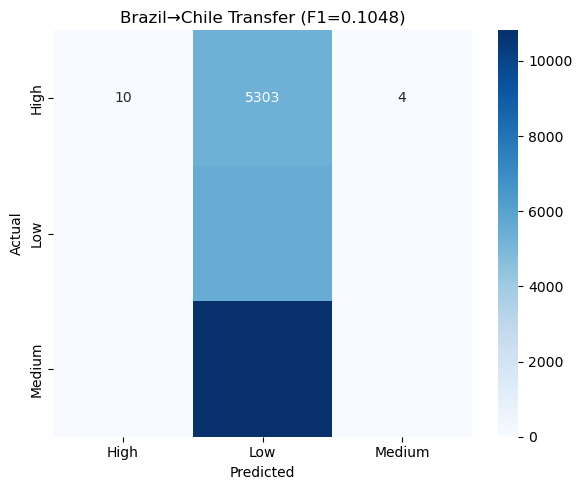


Prediction distribution:
Low       21644
High         14
Medium        4
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns

# --- load Chile ---
df_chile_raw = pd.read_csv(f"{DATA_DIR}/ML_Dataset_100m.csv")
df_chile = df_chile_raw[df_chile_raw["label"] == "Chile"].copy()
print(f"Chile: {len(df_chile)} rows")

X_chile, y_chile = prepare_xy(df_chile)

# align columns
missing = [c for c in X_train_full.columns if c not in X_chile.columns]
extra = [c for c in X_chile.columns if c not in X_train_full.columns]
print(f"Missing in Chile (zero-fill): {missing}")
print(f"Extra in Chile (drop): {extra}")

for c in missing:
    X_chile[c] = 0
X_chile = X_chile[[c for c in X_train_full.columns if c in X_chile.columns]]

# predict
chile_pred = m_final.predict(X_chile.values)
chile_pred_labels = le.inverse_transform(chile_pred)

# evaluate
if y_chile is not None and len(y_chile) > 0:
    y_chile_enc = le.transform(y_chile)
    f1 = f1_score(y_chile_enc, chile_pred, average='weighted')
    print(f"\n=== Brazil → Chile Transfer: F1 = {f1:.4f} ===\n")
    print(classification_report(y_chile_enc, chile_pred, target_names=le.classes_))

    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_chile_enc, chile_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(f'Brazil→Chile Transfer (F1={f1:.4f})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout(); plt.show()

print(f"\nPrediction distribution:\n{pd.Series(chile_pred_labels).value_counts()}")

In [ ]:
# # --- save ---
# out_chile = df_chile[["Latitude", "Longitude"]].copy().reset_index(drop=True)
# out_chile["UHI_Class_True"] = y_chile.values if y_chile is not None else np.nan
# out_chile["UHI_Class_Predicted"] = chile_pred_labels
# out_chile.to_csv(f"{DATA_DIR}/Chile_UHI_Predictions_from_Brazil.csv", index=False)
# print(f"Saved — {len(out_chile)} rows")

In [ ]:
# ============================================================
# Multi-model sweep: Train Brazil → Test Chile
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import (
    GradientBoostingClassifier, RandomForestClassifier, 
    ExtraTreesClassifier, HistGradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import Counter
import time

# --- prep data ---
X_br, y_br = prepare_xy(train_100)
y_br_enc = le.transform(y_br)

df_chile_raw = pd.read_csv(f"{DATA_DIR}/ML_Dataset_100m.csv")
df_chile = df_chile_raw[df_chile_raw["label"] == "Chile"].dropna(subset=["UHI_Class"]).copy()
X_cl, y_cl = prepare_xy(df_chile)
y_cl_enc = le.transform(y_cl)

# align columns
for c in [col for col in X_br.columns if col not in X_cl.columns]:
    X_cl[c] = 0
for c in [col for col in X_cl.columns if col not in X_br.columns]:
    X_br[c] = 0
X_cl = X_cl[X_br.columns]

print(f"Brazil train: {X_br.shape}, Chile test: {X_cl.shape}")
print(f"Brazil classes: {dict(Counter(y_br_enc))}")
print(f"Chile classes:  {dict(Counter(y_cl_enc))}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

StatementMeta(, 46e92ce5-b70a-4cc1-9ca4-9952d043be11, 14, Finished, Available, Finished, False)

Brazil train: (28488, 45), Chile test: (21662, 45)
Brazil classes: {2: 5149, 0: 12748, 1: 10591}
Chile classes:  {1: 5529, 2: 10816, 0: 5317}


In [ ]:
# --- define all pipelines with param grids ---
experiments = {
    "GB_raw": {
        "pipe": Pipeline([("m", GradientBoostingClassifier(random_state=42))]),
        "params": {
            "m__n_estimators": [200, 400],
            "m__max_depth": [4, 6],
            "m__learning_rate": [0.05, 0.1, 0.2],
            "m__subsample": [0.8, 1.0],
            "m__min_samples_leaf": [5, 12],
        },
        "n_iter": 15,
    },
    "XGB_raw": {
        "pipe": Pipeline([("m", XGBClassifier(verbosity=0, eval_metric="mlogloss", random_state=42))]),
        "params": {
            "m__n_estimators": [200, 400],
            "m__max_depth": [4, 6, 8],
            "m__learning_rate": [0.03, 0.1, 0.2],
            "m__subsample": [0.7, 0.8],
            "m__colsample_bytree": [0.7, 0.8],
            "m__min_child_weight": [5, 8, 12],
        },
        "n_iter": 20,
    },
    "RF_raw": {
        "pipe": Pipeline([("m", RandomForestClassifier(class_weight="balanced", random_state=42))]),
        "params": {
            "m__n_estimators": [300, 500],
            "m__max_depth": [6, 8, 12, None],
            "m__min_samples_leaf": [3, 5, 10],
        },
        "n_iter": 12,
    },
    "ExtraTrees_raw": {
        "pipe": Pipeline([("m", ExtraTreesClassifier(class_weight="balanced", random_state=42))]),
        "params": {
            "m__n_estimators": [300, 500],
            "m__max_depth": [6, 8, 12],
            "m__min_samples_leaf": [3, 5, 10],
        },
        "n_iter": 10,
    },
    "HistGB_raw": {
        "pipe": Pipeline([("m", HistGradientBoostingClassifier(random_state=42))]),
        "params": {
            "m__max_iter": [200, 400],
            "m__max_depth": [4, 6, 8],
            "m__learning_rate": [0.03, 0.1, 0.2],
            "m__min_samples_leaf": [5, 12, 20],
        },
        "n_iter": 15,
    },
    "XGB_scaled": {
        "pipe": Pipeline([("scaler", StandardScaler()), ("m", XGBClassifier(verbosity=0, eval_metric="mlogloss", random_state=42))]),
        "params": {
            "m__n_estimators": [300, 500],
            "m__max_depth": [4, 6],
            "m__learning_rate": [0.03, 0.1],
            "m__subsample": [0.7, 0.8],
            "m__min_child_weight": [5, 8],
        },
        "n_iter": 15,
    },
    "KNN_scaled": {
        "pipe": Pipeline([("scaler", StandardScaler()), ("m", KNeighborsClassifier())]),
        "params": {
            "m__n_neighbors": [3, 5, 7, 11, 15],
            "m__metric": ["euclidean", "manhattan"],
            "m__weights": ["uniform", "distance"],
        },
        "n_iter": 15,
    },
    "SVM_scaled": {
        "pipe": Pipeline([("scaler", StandardScaler()), ("m", SVC(class_weight="balanced", random_state=42))]),
        "params": {
            "m__C": [0.1, 1, 10],
            "m__kernel": ["rbf"],
            "m__gamma": ["scale", "auto"],
        },
        "n_iter": 6,
    },
    "Logistic_scaled": {
        "pipe": Pipeline([("scaler", StandardScaler()), ("m", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))]),
        "params": {
            "m__C": [0.01, 0.1, 1, 10],
        },
        "n_iter": 4,
    },
    "XGB_quantile": {
        "pipe": Pipeline([("qt", QuantileTransformer(output_distribution="normal", random_state=42)), ("m", XGBClassifier(verbosity=0, eval_metric="mlogloss", random_state=42))]),
        "params": {
            "m__n_estimators": [300, 500],
            "m__max_depth": [4, 6],
            "m__learning_rate": [0.03, 0.1],
            "m__min_child_weight": [5, 8],
        },
        "n_iter": 12,
    },
}

print(f"Running {len(experiments)} experiments with RandomizedSearchCV (5-fold)")

StatementMeta(, 46e92ce5-b70a-4cc1-9ca4-9952d043be11, 15, Finished, Available, Finished, False)

Running 10 experiments with RandomizedSearchCV (5-fold)


In [ ]:
# --- run all in parallel ---
def run_experiment(name, cfg):
    t0 = time.time()
    search = RandomizedSearchCV(
        cfg["pipe"], cfg["params"], n_iter=cfg["n_iter"],
        cv=cv, scoring="f1_weighted", n_jobs=-1, random_state=42, refit=True
    )
    search.fit(X_br.values, y_br_enc)
    
    # brazil CV score
    cv_f1 = search.best_score_
    
    # brazil train score
    br_pred = search.predict(X_br.values)
    f1_br_train = f1_score(y_br_enc, br_pred, average="weighted")
    
    # chile transfer score
    cl_pred = search.predict(X_cl.values)
    f1_chile = f1_score(y_cl_enc, cl_pred, average="weighted")
    
    elapsed = time.time() - t0
    return {
        "model": name,
        "cv_f1_brazil": round(cv_f1, 4),
        "f1_train_brazil": round(f1_br_train, 4),
        "f1_chile_transfer": round(f1_chile, 4),
        "br_gap": round(abs(f1_br_train - cv_f1), 4),
        "best_params": search.best_params_,
        "time_s": round(elapsed, 1),
        "fitted": search,
        "cl_pred": cl_pred,
    }

results = {}
with ThreadPoolExecutor(max_workers=4) as pool:
    futures = {pool.submit(run_experiment, name, cfg): name for name, cfg in experiments.items()}
    for f in as_completed(futures):
        name = futures[f]
        res = f.result()
        results[name] = res
        print(f"  {name:20s} — CV: {res['cv_f1_brazil']:.4f}  Train: {res['f1_train_brazil']:.4f}  Chile: {res['f1_chile_transfer']:.4f}  Gap: {res['br_gap']:.4f}  ({res['time_s']}s)")

StatementMeta(, 46e92ce5-b70a-4cc1-9ca4-9952d043be11, 16, Finished, Available, Finished, False)

  ExtraTrees_raw       — CV: 0.8811  Train: 0.8946  Chile: 0.1038  Gap: 0.0135  (2185.4s)


  RF_raw               — CV: 0.9449  Train: 0.9652  Chile: 0.1080  Gap: 0.0203  (2382.3s)


  Logistic_scaled      — CV: 0.7156  Train: 0.7177  Chile: 0.1061  Gap: 0.0021  (202.0s)
  XGB_quantile         — CV: 0.9515  Train: 0.9735  Chile: 0.1054  Gap: 0.0220  (242.2s)
  SVM_scaled           — CV: 0.8429  Train: 0.8592  Chile: 0.1038  Gap: 0.0162  (445.2s)


  GB_raw               — CV: 0.9534  Train: 0.9836  Chile: 0.1042  Gap: 0.0303  (4397.5s)
